# 04 - Retrieval Methods: Strategy Comparison

**Phase 4** of the RAG project. We compare 5 retrieval strategies on the same corpus
to identify the best approach depending on the query type:

1. **Similarity Search** (dense) - baseline cosine similarity
2. **MMR** (Maximum Marginal Relevance) - balances relevance and diversity
3. **BM25** (sparse) - keyword-based search, TF-IDF variant
4. **Hybrid** (Ensemble) - combines dense + sparse via RRF
5. **Multi-Query** - the LLM reformulates the question, results are merged

We use **mxbai-embed-large** (1024d, strong overall balance from Phase 3) and
**recursive** chunking (1000 chars, overlap 200) from Phase 2.
The corpus is filtered to exclude `/python/integrations/` pages; this run yields
**2,666 core docs** and **9,137 chunks**.
The benchmark has **5 questions** (3 methodology, 2 results).

### Evaluated Metrics

- **Precision@k** - fraction of top-k results that are relevant
- **Recall@k** - fraction of relevant docs found in the top-k
- **MRR** - reciprocal rank of the first relevant result
- **nDCG@k** - ranking quality (accounts for position)
- **Latency** - retrieval time (ms)
- **Diversity** - average cosine distance between results

---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.retrieval.dense import retrieve_dense, create_dense_retriever, RetrievalStrategyResult
from src.retrieval.sparse import create_bm25_retriever, retrieve_bm25
from src.retrieval.hybrid import create_hybrid_retriever, retrieve_hybrid
from src.retrieval.factory import create_retriever_from_config
from notebooks.utils.display import (
    display_retrieval_results,
    display_strategy_comparison,
    display_category_breakdown,
    display_latency_comparison,
    display_radar_chart,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
    BenchmarkQuestion,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Corpus Preparation and Indexing

We load the corpus, **filter out integration reference pages** (if present), then chunk with
the recursive strategy (Phase 2) and index into ChromaDB with **mxbai-embed-large** (Phase 3).
We also build the BM25 index in memory.

This run: **2,666 cleaned docs -> 2,666 core docs -> 9,137 chunks**.

In [2]:
# Load and clean
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter out /python/integrations/ pages (90% of the corpus, mostly noise).
# Keep: concepts, guides, langgraph, deepagents, top-level integrations (splitters, etc.)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core (filtered)")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Corpus: 2703 docs -> 2666 cleaned -> 2666 core (filtered)
Chunked: 2666 docs -> 9137 chunks


In [3]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION = "retrieval_eval_mxbai"
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")  # warmup
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

# ChromaDB index
client = chromadb.PersistentClient(path=PERSIST_DIR)
try:
    client.delete_collection(COLLECTION)
except Exception:
    pass

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
start = time.perf_counter()
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION,
)
index_time = time.perf_counter() - start
print(f"Indexed in {index_time:.1f}s ({vectorstore._collection.count()} chunks)")

# BM25 index
print("Building BM25 index...")
start = time.perf_counter()
bm25_retriever = create_bm25_retriever(chunks, k=5)
bm25_time = time.perf_counter() - start
print(f"BM25 index built in {bm25_time:.1f}s")

Embedding model: mxbai-embed-large (1024d)
Indexing 9137 chunks into ChromaDB...
Indexed in 137.9s (9137 chunks)
Building BM25 index...
BM25 index built in 0.4s


In [4]:
# Load benchmark questions
questions = load_benchmark_questions(str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json"))

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    print(f"  {cat}: {len(qs)} questions")

Benchmark: 5 questions
  methodology: 3 questions
  results: 2 questions


---
## 2. Dense Similarity Search (baseline)

The simplest strategy: encode the query, find the k nearest neighbors
by cosine distance in ChromaDB.

In [5]:
K = 5

dense_metrics = []
for q in questions:
    result = retrieve_dense(vectorstore, q.query, search_type="similarity", k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "similarity"
    dense_metrics.append(m)

dense_df = pd.DataFrame(dense_metrics)
print("Similarity Search - average metrics:")
print(f"  Precision@{K}: {dense_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {dense_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {dense_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {dense_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {dense_df['latency_ms'].mean():.1f} ms")

Similarity Search - average metrics:
  Precision@5: 0.7600
  Recall@5:    0.7600
  MRR:           0.8667
  nDCG@5:      0.7755
  Latency:       716.8 ms


In [6]:
# Example results for a query
example_q = questions[0]
example_result = retrieve_dense(vectorstore, example_q.query, search_type="similarity", k=K)
print(f"Example: '{example_q.query}'")
print(f"  Results: {example_result.num_results}, Latency: {example_result.elapsed_ms:.1f} ms")
display_retrieval_results(
    example_q.query,
    list(zip(example_result.docs, example_result.scores)),
)

Example: 'What are the primary characteristics and constraints of TinyML systems mentioned in the text?'
  Results: 5, Latency: 638.4 ms


---
## 3. Maximum Marginal Relevance (MMR)

MMR balances relevance and diversity. The `lambda_mult` parameter controls the
trade-off: 1.0 = pure relevance, 0.0 = maximum diversity.

We test 4 values: 0.3, 0.5, 0.7, 0.9.

In [7]:
LAMBDA_VALUES = [0.3, 0.5, 0.7, 0.9]

mmr_all_metrics = []

for lam in LAMBDA_VALUES:
    strategy_name = f"mmr_{lam}"
    print(f"\nMMR lambda={lam}:")
    for q in questions:
        result = retrieve_dense(
            vectorstore, q.query,
            search_type="mmr", k=K, fetch_k=20, lambda_mult=lam,
        )
        m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
        m["strategy"] = strategy_name
        mmr_all_metrics.append(m)

    lam_df = pd.DataFrame([m for m in mmr_all_metrics if m["strategy"] == strategy_name])
    print(f"  Precision@{K}: {lam_df['precision_at_k'].mean():.4f}")
    print(f"  MRR:           {lam_df['mrr'].mean():.4f}")
    print(f"  Latency:       {lam_df['latency_ms'].mean():.1f} ms")

mmr_df = pd.DataFrame(mmr_all_metrics)


MMR lambda=0.3:
  Precision@5: 0.8400
  MRR:           0.9000
  Latency:       1114.4 ms

MMR lambda=0.5:
  Precision@5: 0.8800
  MRR:           0.9000
  Latency:       764.9 ms

MMR lambda=0.7:
  Precision@5: 0.7600
  MRR:           0.8667
  Latency:       875.9 ms

MMR lambda=0.9:
  Precision@5: 0.7600
  MRR:           0.8667
  Latency:       985.6 ms


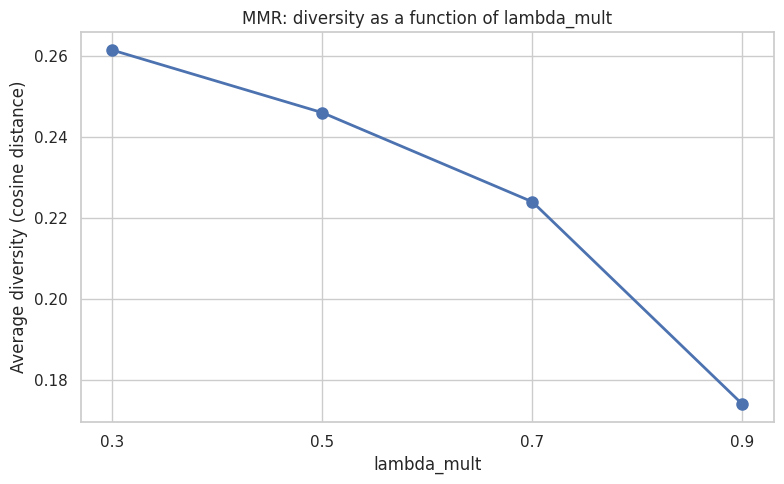


Average diversity by lambda:


,avg_diversity
lambda,
0.3,0.2614
0.5,0.2459
0.7,0.2239
0.9,0.1740


In [8]:
# Diversity vs relevance comparison by lambda
from notebooks.utils.metrics import diversity_score

diversity_data = []

# Pick 3 representative queries for diversity analysis
sample_queries = questions[:3]

for lam in LAMBDA_VALUES:
    for q in sample_queries:
        result = retrieve_dense(
            vectorstore, q.query,
            search_type="mmr", k=K, fetch_k=20, lambda_mult=lam,
        )
        div = diversity_score(result.docs, embeddings)
        diversity_data.append({
            "lambda": lam,
            "query": q.query[:50],
            "diversity": round(div, 4),
        })

div_df = pd.DataFrame(diversity_data)
div_summary = div_df.groupby("lambda")["diversity"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(div_summary.index, div_summary.values, "o-", linewidth=2, markersize=8)
ax.set_xlabel("lambda_mult")
ax.set_ylabel("Average diversity (cosine distance)")
ax.set_title("MMR: diversity as a function of lambda_mult")
ax.set_xticks(LAMBDA_VALUES)
plt.tight_layout()
plt.show()

print("\nAverage diversity by lambda:")
display(div_summary.to_frame("avg_diversity").round(4))

---
## 4. Sparse BM25 Search

BM25 is a keyword-based method (TF-IDF variant).
It excels when the query contains specific terms
(class names, functions, error messages).

In [9]:
bm25_metrics = []
for q in questions:
    result = retrieve_bm25(bm25_retriever, q.query)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "bm25"
    bm25_metrics.append(m)

bm25_df = pd.DataFrame(bm25_metrics)
print("BM25 - average metrics:")
print(f"  Precision@{K}: {bm25_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {bm25_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {bm25_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {bm25_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {bm25_df['latency_ms'].mean():.1f} ms")

BM25 - average metrics:
  Precision@5: 0.6000
  Recall@5:    0.6000
  MRR:           0.8667
  nDCG@5:      0.6280
  Latency:       34.8 ms


In [10]:
# BM25 shines on methodology queries
tech_q = [q for q in questions if q.category == "methodology"][0]
bm25_result = retrieve_bm25(bm25_retriever, tech_q.query)
dense_result = retrieve_dense(vectorstore, tech_q.query, search_type="similarity", k=K)

print(f"Methodology query: '{tech_q.query}'")
print(f"\n--- BM25 ---")
for i, doc in enumerate(bm25_result.docs[:3], 1):
    title = doc.metadata.get("source", "?")[:60]
    print(f"  {i}. {title}")

print(f"\n--- Dense ---")
for i, doc in enumerate(dense_result.docs[:3], 1):
    title = doc.metadata.get("source", "?")[:60]
    print(f"  {i}. {title} (score: {dense_result.scores[i-1]:.4f})")

Methodology query: 'What are the primary characteristics and constraints of TinyML systems mentioned in the text?'

--- BM25 ---
  1. 13.Machine-Learning-Systems.pdf
  2. 13.Machine-Learning-Systems.pdf
  3. 13.Machine-Learning-Systems.pdf

--- Dense ---
  1. 13.Machine-Learning-Systems.pdf (score: 0.3710)
  2. 13.Machine-Learning-Systems.pdf (score: 0.4261)
  3. 13.Machine-Learning-Systems.pdf (score: 0.4360)


---
## 5. Hybrid Search (Ensemble)

The EnsembleRetriever combines results from multiple retrievers
via Reciprocal Rank Fusion (RRF). We test 3 weight configurations
\[dense, sparse\]:

- **0.7/0.3** - favors semantic similarity
- **0.5/0.5** - equal weights
- **0.3/0.7** - favors keywords

In [11]:
WEIGHT_CONFIGS = [
    ([0.7, 0.3], "0.7/0.3"),
    ([0.5, 0.5], "0.5/0.5"),
    ([0.3, 0.7], "0.3/0.7"),
]

dense_ret = create_dense_retriever(vectorstore, search_type="similarity", k=10)

hybrid_all_metrics = []

for weights, label in WEIGHT_CONFIGS:
    bm25_ret = create_bm25_retriever(chunks, k=10)
    hybrid_ret = create_hybrid_retriever(dense_ret, bm25_ret, weights=weights)
    strategy_name = f"hybrid_{label}"
    print(f"\nHybrid [{label}]:")

    for q in questions:
        result = retrieve_hybrid(hybrid_ret, q.query, weights_label=label)
        # Limit to K results
        result_docs = result.docs[:K]
        m = compute_retrieval_metrics(result_docs, q, result.elapsed_ms, k=K)
        m["strategy"] = strategy_name
        hybrid_all_metrics.append(m)

    lbl_df = pd.DataFrame([m for m in hybrid_all_metrics if m["strategy"] == strategy_name])
    print(f"  Precision@{K}: {lbl_df['precision_at_k'].mean():.4f}")
    print(f"  MRR:           {lbl_df['mrr'].mean():.4f}")
    print(f"  Latency:       {lbl_df['latency_ms'].mean():.1f} ms")

hybrid_df = pd.DataFrame(hybrid_all_metrics)


Hybrid [0.7/0.3]:
  Precision@5: 0.7600
  MRR:           0.8667
  Latency:       630.5 ms

Hybrid [0.5/0.5]:
  Precision@5: 0.7200
  MRR:           0.8400
  Latency:       555.3 ms

Hybrid [0.3/0.7]:
  Precision@5: 0.6000
  MRR:           0.8667
  Latency:       526.6 ms


---
## 6. Multi-Query Retriever

The LLM (Mistral 7B via Ollama) generates N reformulations of the question.
Each variant retrieves documents, then results are merged and deduplicated.

> **Note**: this strategy is slower because each query requires
> an LLM call (~2-5 seconds per reformulation).

In [12]:
from langchain_ollama import ChatOllama
from langchain_classic.retrievers.multi_query import MultiQueryRetriever

llm = ChatOllama(model="mistral:7b", temperature=0.3)

base_retriever = create_dense_retriever(vectorstore, search_type="similarity", k=K)
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=base_retriever,
    llm=llm,
)

print(f"Multi-Query Retriever: base=similarity(k={K}), LLM=mistral:7b")
print(f"Benchmarking on {len(questions)} questions (may take a few minutes)...\n")

mq_metrics = []
for i, q in enumerate(questions):
    start = time.perf_counter()
    try:
        docs = multi_query_retriever.invoke(q.query)
    except Exception as e:
        print(f"  [{q.id}] Error: {e}")
        docs = []
    elapsed_ms = (time.perf_counter() - start) * 1000

    docs = docs[:K]  # limit to K
    m = compute_retrieval_metrics(docs, q, elapsed_ms, k=K)
    m["strategy"] = "multi_query"
    mq_metrics.append(m)

    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(questions)} questions processed...")

mq_df = pd.DataFrame(mq_metrics)
print(f"\nMulti-Query - average metrics:")
print(f"  Precision@{K}: {mq_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {mq_df['mrr'].mean():.4f}")
print(f"  Latency:       {mq_df['latency_ms'].mean():.1f} ms")

Multi-Query Retriever: base=similarity(k=5), LLM=mistral:7b
Benchmarking on 5 questions (may take a few minutes)...

  5/5 questions processed...

Multi-Query - average metrics:
  Precision@5: 0.8000
  MRR:           0.8000
  Latency:       4654.8 ms


---
## 7. Global Comparison

Aggregated metrics across all strategies.

In [13]:
# Combine all results
all_metrics_df = pd.concat([dense_df, mmr_df, bm25_df, hybrid_df, mq_df], ignore_index=True)

# Aggregate per strategy
summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=('precision_at_k', 'mean'),
        avg_recall=('recall_at_k', 'mean'),
        avg_mrr=('mrr', 'mean'),
        avg_ndcg=('ndcg_at_k', 'mean'),
        avg_latency_ms=('latency_ms', 'mean'),
    )
    .round(4)
)

print("Global comparison of retrieval strategies:")
display_strategy_comparison(summary.reset_index())

Global comparison of retrieval strategies:


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms
0,bm25,0.600000,0.600000,0.866700,0.628000,34.8
1,hybrid_0.3/0.7,0.600000,0.600000,0.866700,0.641600,526.6
2,hybrid_0.5/0.5,0.720000,0.720000,0.840000,0.741600,555.3
3,hybrid_0.7/0.3,0.760000,0.760000,0.866700,0.775500,630.5
4,mmr_0.3,0.840000,0.840000,0.900000,0.842800,1114.4
5,mmr_0.5,0.880000,0.880000,0.900000,0.872000,764.9
6,mmr_0.7,0.760000,0.760000,0.866700,0.770800,875.9
7,mmr_0.9,0.760000,0.760000,0.866700,0.775500,985.6
8,multi_query,0.800000,0.800000,0.800000,0.800000,4654.8
9,similarity,0.760000,0.760000,0.866700,0.775500,716.8


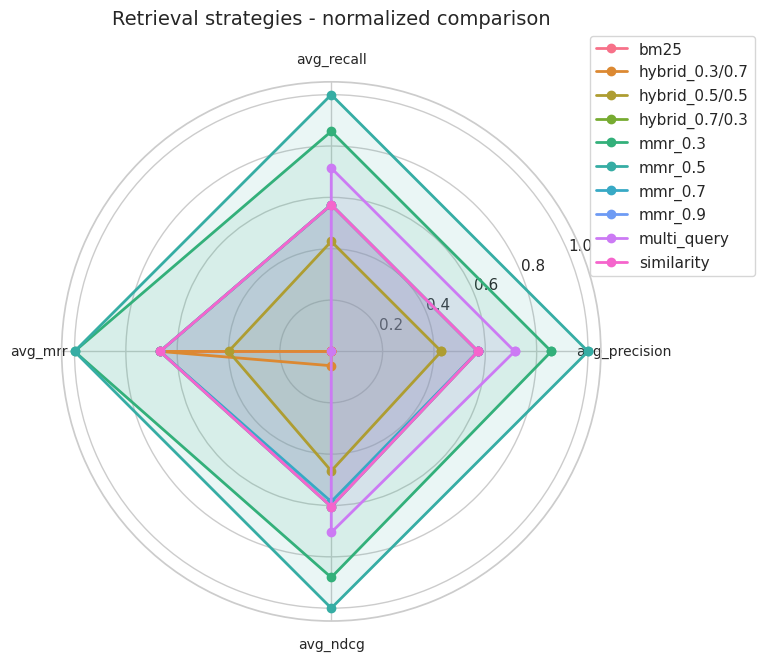

In [14]:
# Radar chart (normalized metrics, excluding latency)
radar_df = summary.reset_index().copy()

# Normalize each metric to [0, 1]
radar_metrics = ["avg_precision", "avg_recall", "avg_mrr", "avg_ndcg"]
radar_norm = radar_df.copy()
for col in radar_metrics:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    if col_max > col_min:
        radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min)
    else:
        radar_norm[col] = 0.5

display_radar_chart(
    radar_norm,
    metrics=radar_metrics,
    strategy_col="strategy",
    title="Retrieval strategies - normalized comparison",
)

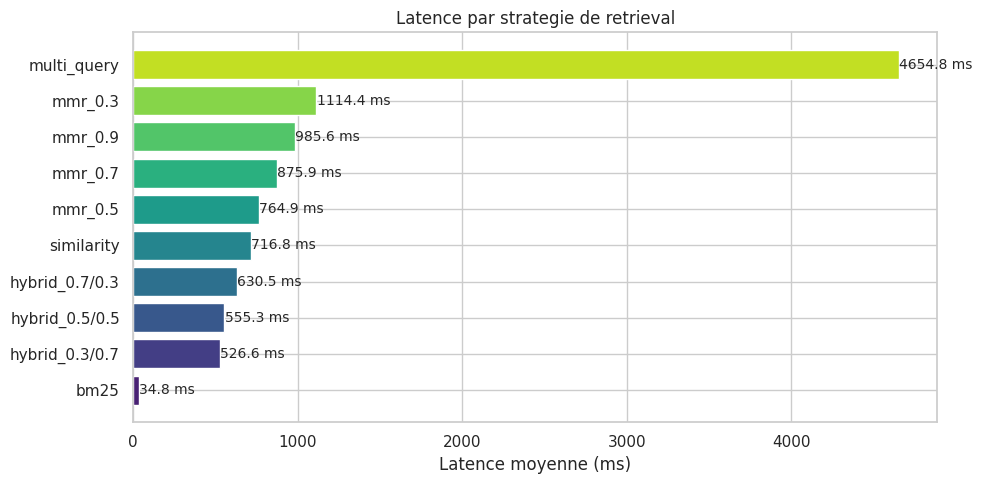

In [15]:
# Latency comparison
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

---
## 8. Analysis by Query Type

Not all strategies perform equally well for each question type.
This benchmark has two categories:
- **methodology**: best precision with MMR (lambda=0.3)
- **results**: best precision with MMR (lambda=0.5)

In [16]:
# Per-category breakdown
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(
        avg_precision=('precision_at_k', 'mean'),
        avg_mrr=('mrr', 'mean'),
        avg_latency_ms=('latency_ms', 'mean'),
    )
    .round(4)
    .reset_index()
)

# Best strategy per category
print("Best strategy per category (Precision@k):")
best_per_cat = cat_summary.loc[
    cat_summary.groupby("category")["avg_precision"].idxmax()
][["category", "strategy", "avg_precision"]]
display(best_per_cat.set_index("category"))

print("\nBest strategy per category (MRR):")
best_mrr = cat_summary.loc[
    cat_summary.groupby("category")["avg_mrr"].idxmax()
][["category", "strategy", "avg_mrr"]]
display(best_mrr.set_index("category"))

Best strategy per category (Precision@k):


,strategy,avg_precision
category,,
methodology,mmr_0.3,1.0
results,mmr_0.5,0.7



Best strategy per category (MRR):


,strategy,avg_mrr
category,,
methodology,bm25,1.00
results,mmr_0.3,0.75


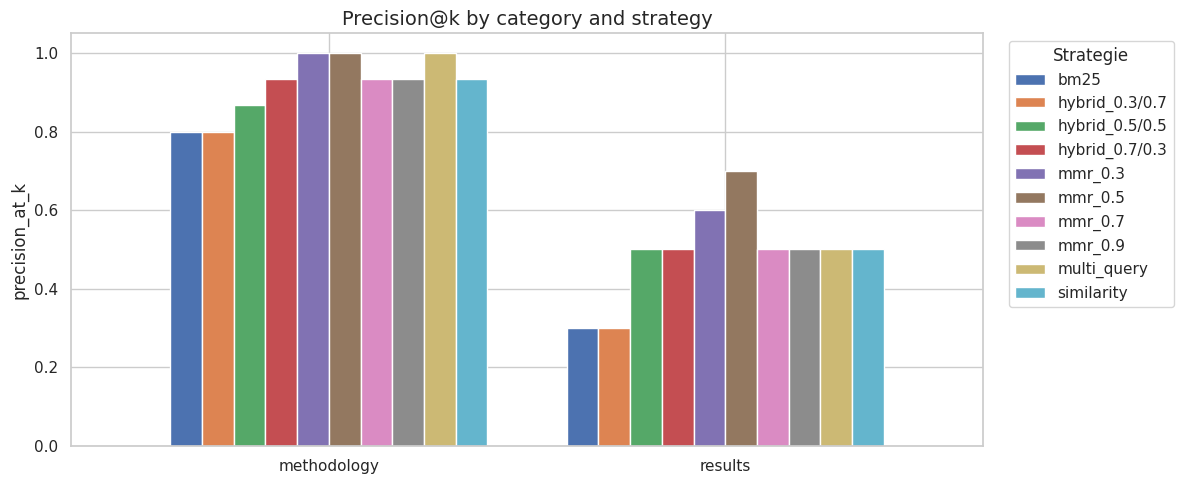

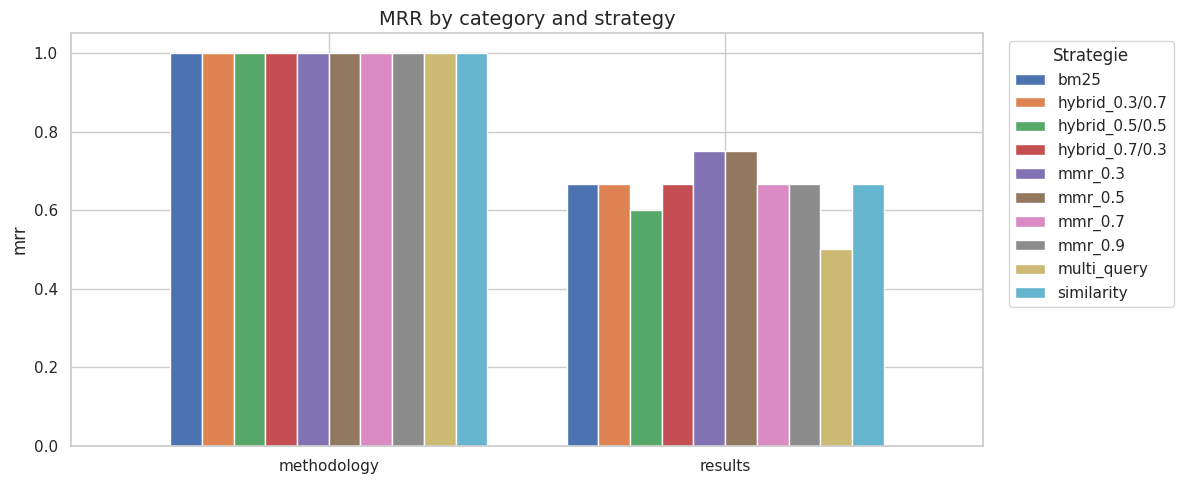

In [17]:
display_category_breakdown(
    all_metrics_df, metric="precision_at_k",
    title="Precision@k by category and strategy",
)

display_category_breakdown(
    all_metrics_df, metric="mrr",
    title="MRR by category and strategy",
)

---
## 9. Save Results

In [18]:
# Build results output
results_output = {
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "strategies": {},
    "best_per_category": {},
    "benchmark_queries": [q.query for q in questions],
}

# Per-strategy aggregates
for strategy_name, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["strategies"][strategy_name] = entry

# Best per category
for cat in sorted(categories.keys()):
    cat_data = cat_summary[cat_summary["category"] == cat]
    best = cat_data.loc[cat_data["avg_precision"].idxmax()]
    results_output["best_per_category"][cat] = best["strategy"]

# Save
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "retrieval_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/retrieval_comparison.json


---
## 10. Cleanup

In [19]:
# Clean up evaluation collection
try:
    client.delete_collection(COLLECTION)
    print(f"Collection '{COLLECTION}' deleted.")
except Exception:
    pass

# Also clean up stale nomic collection from previous runs
try:
    client.delete_collection("retrieval_eval_nomic")
    print("Deleted stale 'retrieval_eval_nomic' collection.")
except Exception:
    pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Collection 'retrieval_eval_mxbai' deleted.
Remaining collections: ['query_translation_eval', 'course_qa_naive']


---
## 11. Summary & Observations

### Corpus Filtering

This run used **2,666 cleaned docs**, all retained as core docs after filtering,
and produced **9,137 chunks** with recursive splitting (1000/200).
The benchmark set contains **5 questions** across **methodology (3)** and **results (2)**.

### Results

| Strategy | Precision@5 | MRR | nDCG@5 | Latency | Notes |
|---|---|---|---|---|---|
| Similarity | 0.760 | 0.867 | 0.776 | 717 ms | Strong baseline |
| MMR (lambda=0.5) | **0.880** | **0.900** | **0.872** | 765 ms | Best overall |
| MMR (lambda=0.3) | 0.840 | 0.900 | 0.843 | 1114 ms | Best for methodology |
| BM25 | 0.600 | 0.867 | 0.628 | **35 ms** | Fastest, lower nDCG |
| Hybrid (0.7/0.3) | 0.760 | 0.867 | 0.776 | 631 ms | Matches dense at higher cost |
| Hybrid (0.5/0.5) | 0.720 | 0.840 | 0.742 | 555 ms | Balanced |
| Multi-Query | 0.800 | 0.800 | 0.800 | 4655 ms | Slowest, modest gains |

### Best Strategy by Query Type

| Category | Best (Precision) | Best (MRR) | Note |
|---|---|---|---|
| methodology | mmr_0.3 (1.000) | mmr_0.3 (1.000) | Clear winner on methodology |
| results | mmr_0.5 (0.700) | mmr_0.5 (0.750) | Best on results queries |

### Key Takeaways

1. **MMR (lambda=0.5) is the best overall strategy** with the highest precision and nDCG,
   at a moderate latency cost versus dense similarity.

2. **Dense similarity remains a strong baseline** with identical MRR to several variants,
   and lower latency than MMR and hybrid.

3. **BM25 is extremely fast** and competitive on MRR, but lags on nDCG and overall ranking
   quality for semantic queries.

4. **Hybrid search did not beat dense on this benchmark** and added significant latency.

5. **Multi-Query is not worth the cost here** - it is ~4.7s per query with only modest gains.

### Evaluation Limitations

- The benchmark is small (5 questions), so differences may be noisy.
- Relevance annotations use source matching; some chunks from a relevant page may not
  answer the question directly.
- Full end-to-end answer evaluation arrives in Phase 9 (RAGAS).

### Recommendation

**Use MMR (lambda=0.5) as the default retriever** for this corpus.
If latency is critical, use **similarity search** or **BM25** depending on query style.

### Next Step: Phase 5 - Query Translation

We will explore query reformulation techniques (HyDE, RAG Fusion, Step-Back,
Decomposition) to improve retrieval upstream, particularly for results-style queries.
